In [2]:
RMSD_cutoff = 0.4     # 0.4nm = 4 Å
Protacname = "1P"

In [ ]:
!echo "2 2" | gmx cluster \
-f <PATH>/protac1_simulation_p/ligand_hb.xtc \
-s <PATH>/protac1_simulation_p/ligand_hb.pdb \
-method gromos \
-cutoff {RMSD_cutoff} \
-o clusters_{Protacname}_{RMSD_cutoff}.xpm \
-g cluster_{Protacname}_{RMSD_cutoff}.log \
-cl representative_{Protacname}_{RMSD_cutoff}.pdb

                 :-) GROMACS - gmx cluster, 2025.1-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.1/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.1
Working dir:  /Users/farjal/Library/CloudStorage/OneDrive-Chalmers/Documents/Generator/Moltiverse_analysis/3.Simulation_and_analysis/new_Set/2.Simulation_dardel_finalset/All_data/Cluster/1P
Command line:
  gmx cluster -f ../../../3895_simulation_p/ligand_hb.xtc -s ../../../3895_simulation_p/ligand_hb.pdb -method gromos -cutoff 0.2 -o clusters_1P_0.2.xpm -g cluster_1P_0.2.log -cl representative_1P_0.2.pdb

Using gromos method for clustering

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS versi

In [ ]:
# !echo "2 2" :

#Select group for least squares fit and RMSD calculation:
#Group     0 (         System) has    90 elements
#Group     1 (          Other) has    90 elements
#Group     2 (            protac) has    90 elements
#Select a group: 2
#Selected 2: 'protac'

#Select group for output:
#Group     0 (         System) has    90 elements
#Group     1 (          Other) has    90 elements
#Group     2 (            protac) has    90 elements
#Select a group: 2

In [ ]:
!mv representative.pdb representative_{Protacname}.pdb
!mv clusters.xpm clusters_{Protacname}.xpm
!mv rmsd-dist.xvg rmsd-dist_{Protacname}.xvg

In [4]:
import pandas as pd

log_file = f"cluster_{Protacname}_{RMSD_cutoff}.log"

clusters = []

with open(log_file, "r") as f:
    for line in f:
        parts = line.split("|")

        # cluster table lines have at least 4 columns separated by |
        if len(parts) >= 4:
            left = parts[0].strip()

            # only lines starting with cluster number
            if left.isdigit():
                cluster_id = int(left)

                # first value after first | is #st
                st = int(parts[1].split()[0])

                clusters.append({
                    "cluster": cluster_id,
                    "st": st
                })

df = pd.DataFrame(clusters)
df["percentage"] = df["st"] / df["st"].sum() * 100

df

,cluster,st,percentage
0,1,4961,99.200160
1,2,38,0.759848
2,3,2,0.039992


In [5]:
import py3Dmol

pdb_file = f"representative_{Protacname}_{RMSD_cutoff}.pdb"   # multi-model PDB from gmx cluster

models_to_show = [1, 2, 3]

view = py3Dmol.view(width=1000, height=400, viewergrid=(1, 3))

for i, model_id in enumerate(models_to_show):
    with open(pdb_file) as f:
        pdb_data = f.read()

    view.addModelsAsFrames(pdb_data, "pdb", viewer=(0, i))

    # show only requested model/state
    view.setFrame(model_id - 1, viewer=(0, i))

    view.setStyle({"stick": {}}, viewer=(0, i))
    view.addLabel(
        f"Model {model_id}",
        {
            "position": {"x": -4, "y": -5, "z": 3},
            "backgroundColor": "white",
            "fontColor": "black",
            "fontSize": 14,
        },
        viewer=(0, i),
    )
    view.zoomTo(viewer=(0, i))

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
import py3Dmol

pdb_file = f"representative_{Protacname}_{RMSD_cutoff}.pdb"

with open(pdb_file, "r") as f:
    pdb_data = f.read()

view = py3Dmol.view(width=900, height=650)
view.addModelsAsFrames(pdb_data, "pdb")

view.setStyle({"stick": {}})
view.animate({"loop": "forward", "interval": 1000})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

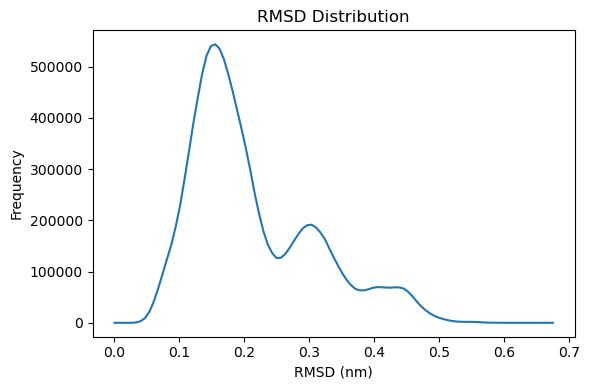

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = []
y = []

with open(f"rmsd-dist_{Protacname}.xvg") as f:
    for line in f:
        if line.startswith(("#", "@")):
            continue

        parts = line.split()

        if len(parts) >= 2:
            x.append(float(parts[0]))
            y.append(float(parts[1]))

x = np.array(x)
y = np.array(y)

plt.figure(figsize=(6,4))
plt.plot(x, y)

plt.xlabel("RMSD (nm)")
plt.ylabel("Frequency")
plt.title("RMSD Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------ CALCULATION: 3D PSA + Rg + CLUSTER % ------------------

import numpy as np
import pandas as pd
import mdtraj as md

# files
log_file = f"cluster_{Protacname}_{RMSD_cutoff}.log"
pdb_file = f"representative_{Protacname}_{RMSD_cutoff}.pdb"
output_csv = f"representative_3dpsa_rg_percent_{Protacname}_{RMSD_cutoff}.csv"

# ------------------ READ CLUSTER LOG AND CALCULATE % ------------------

clusters = []

with open(log_file, "r") as f:
    for line in f:
        parts = line.split("|")

        if len(parts) >= 4:
            left = parts[0].strip()

            if left.isdigit():
                cluster_id = int(left)
                st = int(parts[1].split()[0])

                clusters.append({
                    "cluster": cluster_id,
                    "st": st
                })

df_cluster = pd.DataFrame(clusters)
df_cluster["percentage"] = df_cluster["st"] / df_cluster["st"].sum() * 100

# ------------------ LOAD REPRESENTATIVE PDB ------------------

traj = md.load(pdb_file)

# Keep all models
traj5 = traj[:]

# ------------------ SELECT O, N, AND H ATTACHED TO O/N ------------------

polar_atoms = set()

for atom in traj5.topology.atoms:
    elem = atom.element.symbol if atom.element is not None else ""

    if elem in {"N", "O"}:
        polar_atoms.add(atom.index)

        for atom1, atom2 in traj5.topology.bonds:
            if atom1 == atom and atom2.element is not None and atom2.element.symbol == "H":
                polar_atoms.add(atom2.index)
            elif atom2 == atom and atom1.element is not None and atom1.element.symbol == "H":
                polar_atoms.add(atom1.index)

polar_atoms = sorted(polar_atoms)

if not polar_atoms:
    raise ValueError("No N/O atoms or attached H atoms found.")

# ------------------ CALCULATE 3D PSA AND Rg ------------------

sasa = md.shrake_rupley(traj5, mode="atom")  # nm²

# 3D PSA = SASA of O/N + attached H, converted nm² to Å²
psa = sasa[:, polar_atoms].sum(axis=1) * 100.0

# Rg converted nm to Å
rg = md.compute_rg(traj5) * 10.0

df_rep = pd.DataFrame({
    "model": np.arange(1, traj5.n_frames + 1),
    "3D_PSA_A2": psa,
    "Rg_A": rg
})

# ------------------ ADD CLUSTER PERCENTAGE ------------------

df_rep = df_rep.merge(
    df_cluster[["cluster", "st", "percentage"]],
    left_on="model",
    right_on="cluster",
    how="left"
)

df_rep = df_rep.drop(columns=["cluster"])

df_rep = df_rep[[
    "model",
    "st",
    "percentage",
    "3D_PSA_A2",
    "Rg_A"
]]

# ------------------ SAVE ------------------

df_rep.to_csv(output_csv, index=False)

print(f"Saved: {output_csv}")
print(f"Polar atoms used: {len(polar_atoms)}")
print(f"Min 3D PSA: {psa.min():.2f} Å²")
print(f"Max 3D PSA: {psa.max():.2f} Å²")

df_rep

Saved: representative_3dpsa_rg_percent_1P_0.4.csv
Polar atoms used: 15
Min 3D PSA: 179.25 Å²
Max 3D PSA: 225.84 Å²


,model,st,percentage,3D_PSA_A2,Rg_A
0,1,4961,99.200160,190.728577,5.806835
1,2,38,0.759848,179.251617,4.886289
2,3,2,0.039992,225.836761,5.484886
